<a href="https://colab.research.google.com/github/kartikwadhwa89/robo-advisor-risk-classifier/blob/main/Robo_Advisor_Risk_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robo-Advisor Risk-Profile Classifier

**Business problem:** Automatically classify a client's risk tolerance (Conservative / Moderate / Aggressive) so the robo-advisor can assign the correct equity:debt allocation without manual review.

**Models compared:** Logistic Regression, Decision Tree, Random Forest
**Evaluation:** Accuracy, Precision, Recall, F1, Confusion Matrix

> Run cells top to bottom (Runtime → Run all).

In [ ]:
!pip install -q scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

np.random.seed(42)

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Step 1: Create synthetic client data

Replace this cell with your real robo-advisor's questionnaire data once you have it — the model code below doesn't change.

In [ ]:
N = 600

age = np.random.randint(21, 65, N)
annual_income = np.random.randint(300000, 3000000, N)          # INR
investment_horizon = np.random.randint(1, 30, N)                # years
monthly_savings_pct = np.round(np.random.uniform(2, 40, N), 1)  # % of income saved
loss_tolerance_score = np.random.randint(1, 11, N)              # 1-10 questionnaire score
experience = np.random.choice(["Beginner", "Intermediate", "Expert"], N,
                               p=[0.5, 0.35, 0.15])
dependents = np.random.randint(0, 4, N)

# Rule-based ground truth WITH noise (mimics how real risk categories are
# derived from a weighted questionnaire, plus real-world randomness)
exp_score_map = {"Beginner": 0, "Intermediate": 1, "Expert": 2}
raw_score = (
    (65 - age) * 0.4
    + (investment_horizon) * 1.5
    + loss_tolerance_score * 4
    + np.array([exp_score_map[e] for e in experience]) * 8
    - dependents * 3
    + np.random.normal(0, 8, N)
)

risk_category = pd.cut(
    raw_score,
    bins=[-np.inf, 40, 70, np.inf],
    labels=["Conservative", "Moderate", "Aggressive"]
)

df = pd.DataFrame({
    "Age": age,
    "Annual_Income": annual_income,
    "Investment_Horizon_Years": investment_horizon,
    "Monthly_Savings_Pct": monthly_savings_pct,
    "Loss_Tolerance_Score": loss_tolerance_score,
    "Experience": experience,
    "Dependents": dependents,
    "Risk_Category": risk_category
})

print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['Risk_Category'].value_counts()}")
df.head(10)

Shape: (600, 8)

Class distribution:
Risk_Category
Moderate        330
Aggressive      141
Conservative    129
Name: count, dtype: int64


,Age,Annual_Income,Investment_Horizon_Years,Monthly_Savings_Pct,Loss_Tolerance_Score,Experience,Dependents,Risk_Category
0,59,748345,2,7.8,10,Intermediate,3,Conservative
1,49,1049074,21,19.2,9,Beginner,2,Moderate
2,35,2179490,12,22.2,2,Intermediate,1,Conservative
3,63,2926188,3,2.7,6,Beginner,2,Conservative
4,28,1090141,20,32.3,4,Beginner,3,Conservative
5,41,2848167,26,13.2,4,Expert,3,Moderate
6,59,1754908,22,36.6,5,Beginner,3,Moderate
7,39,2553694,12,38.8,3,Beginner,1,Moderate
8,43,605062,24,9.0,1,Intermediate,2,Moderate
9,31,1912162,17,19.6,8,Expert,2,Aggressive


## Step 2: Feature selection & preprocessing

In [ ]:
le_exp = LabelEncoder()
df["Experience_Encoded"] = le_exp.fit_transform(df["Experience"])

features = ["Age", "Annual_Income", "Investment_Horizon_Years",
            "Monthly_Savings_Pct", "Loss_Tolerance_Score",
            "Experience_Encoded", "Dependents"]
target = "Risk_Category"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 450 | Test size: 150


## Step 3: Train & compare 3 classification models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
predictions = {}
fitted_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    predictions[name] = preds
    fitted_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 3),
        "Precision": round(precision_score(y_test, preds, average="weighted"), 3),
        "Recall": round(recall_score(y_test, preds, average="weighted"), 3),
        "F1_Score": round(f1_score(y_test, preds, average="weighted"), 3),
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.807,0.808,0.807,0.807
1,Decision Tree,0.713,0.712,0.713,0.707
2,Random Forest,0.787,0.792,0.787,0.784


## Step 4: Confusion matrix for the best model

Best model by F1-score: Logistic Regression


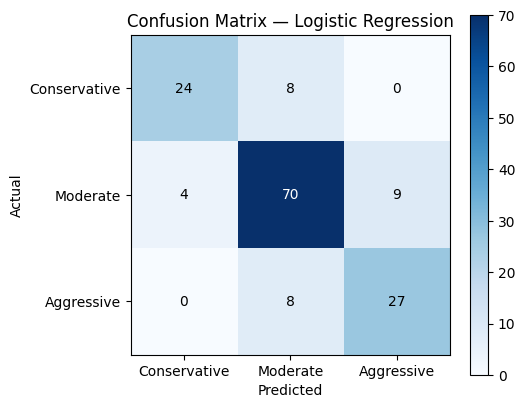

              precision    recall  f1-score   support

  Aggressive       0.75      0.77      0.76        35
Conservative       0.86      0.75      0.80        32
    Moderate       0.81      0.84      0.83        83

    accuracy                           0.81       150
   macro avg       0.81      0.79      0.80       150
weighted avg       0.81      0.81      0.81       150



In [ ]:
best_model_name = results_df.sort_values("F1_Score", ascending=False).iloc[0]["Model"]
print(f"Best model by F1-score: {best_model_name}")

best_preds = predictions[best_model_name]
labels = ["Conservative", "Moderate", "Aggressive"]
cm = confusion_matrix(y_test, best_preds, labels=labels)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_test, best_preds))

## Step 5: Feature importance (Random Forest)

Which questionnaire inputs actually drive the risk category? This is your XAI / SHAP-lite angle for the Responsible AI slide.

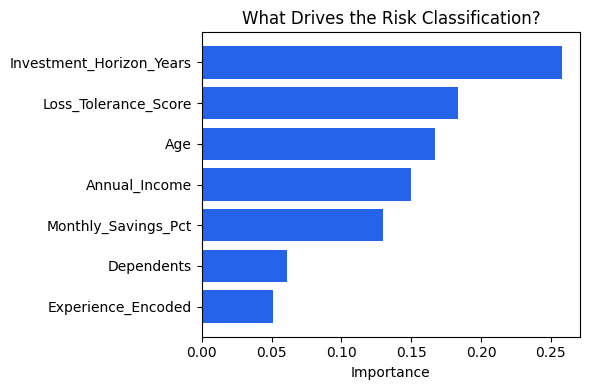

,Feature,Importance
2,Investment_Horizon_Years,0.257996
4,Loss_Tolerance_Score,0.183393
0,Age,0.166736
1,Annual_Income,0.150006
3,Monthly_Savings_Pct,0.129572
6,Dependents,0.061257
5,Experience_Encoded,0.051041


In [ ]:
rf = fitted_models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.barh(importance_df["Feature"], importance_df["Importance"], color="#2563eb")
ax2.invert_yaxis()
ax2.set_xlabel("Importance")
ax2.set_title("What Drives the Risk Classification?")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

importance_df

## Step 6: Live demo — plug into robo-advisor allocation logic

In [ ]:
ALLOCATION_MAP = {
    "Conservative": {"Equity": "20%", "Debt": "70%", "Gold": "10%"},
    "Moderate":     {"Equity": "50%", "Debt": "40%", "Gold": "10%"},
    "Aggressive":   {"Equity": "80%", "Debt": "15%", "Gold": "5%"},
}

new_client = pd.DataFrame([{
    "Age": 24,
    "Annual_Income": 900000,
    "Investment_Horizon_Years": 15,
    "Monthly_Savings_Pct": 25,
    "Loss_Tolerance_Score": 8,
    "Experience_Encoded": le_exp.transform(["Beginner"])[0],
    "Dependents": 0
}])

predicted_risk = rf.predict(new_client)[0]
print("New client profile:")
display(new_client)
print(f"\nPredicted Risk Category: {predicted_risk}")
print(f"Recommended Allocation: {ALLOCATION_MAP[predicted_risk]}")

New client profile:


,Age,Annual_Income,Investment_Horizon_Years,Monthly_Savings_Pct,Loss_Tolerance_Score,Experience_Encoded,Dependents
0,24,900000,15,25,8,0,0



Predicted Risk Category: Moderate
Recommended Allocation: {'Equity': '50%', 'Debt': '40%', 'Gold': '10%'}


## Notes for your case study

- Swap the synthetic data in Step 1 for your robo-advisor's real questionnaire inputs when available — nothing else in the notebook needs to change.
- Logistic Regression is usually the most defensible choice for a regulated advisory use case (interpretable coefficients vs. Random Forest's black-box feel).
- Save `confusion_matrix.png` and `feature_importance.png` (auto-saved to Colab's file panel) for your PPT slides 6 and 8.